# CEFI Northeast Pacific Icechunk creation notebook: Daily regrid

This notebook builds an Icechunk repository from NOAA CEFI Northeast Pacific regional MOM6 NetCDF files. CEFI is NOAA's Changing Ecosystems and Fisheries Initiative, which provides information about past and future conditions for U.S. coastal regions and supports access to regional ocean model outputs for fisheries, ecosystem, and management applications.

The source data are public NetCDF files in:

```text
s3://noaa-oar-cefi-regional-mom6-pds/northeast_pacific/full_domain/hindcast/monthly/regrid/r20250912
```

The workflow here uses VirtualiZarr to create virtual references to the original NetCDF chunks, then writes those references into an Icechunk repository on Source Cooperative. The large data arrays are not copied into Icechunk; Icechunk stores metadata and references back to the original NOAA S3 objects.

## Workflow

1. List the source NetCDF files and group them by variable.
2. Configure VirtualiZarr and Icechunk so virtual chunks can point back to the public CEFI bucket.
3. Open each NetCDF file as a virtual xarray Dataset.
4. Write or append virtual references into an Icechunk repository.
5. Reopen the Icechunk store with xarray and test access/plotting.

Notes from this first pass:

- Some variables are stored as one file per year (group1).
- Other variables are stored as a single full-period file (group2).
- Some source files have time-coordinate problems or different final dates, so the notebook includes checks before merging variables.
- For virtual/chunked arrays, slice indexing is often safer than scalar indexing when plotting small subsets.

**Chunking and performance note** This Icechunk repository is a virtual access layer: the original CEFI NetCDF files remain unchanged in the NOAA S3 bucket, and Icechunk stores references back to those source chunks. When yearly files are appended into a longer virtual array, the opened dataset may present a regular logical chunk grid, for example time=100, even though each source year has its own chunk structure, such as 100, 100, 100, 65 for a 365-day file. This regular logical layout is convenient for xarray, Dask, and ML-style workflows, but it does not mean the source data were physically rechunked. Some logical chunks may span more than one source chunk or even cross a source-file boundary, which can require extra range reads, decompression, and stitching at read time. For this reason, the dataset should be viewed as a cloud-native virtual access product rather than a fully rechunked, performance-optimized training store.

**Why yearly-file and full-period-file variables are stored separately** Some CEFI variables are stored as one file per year, while others are stored as a single full-period file. These two layouts cannot be cleanly merged in this virtual-only workflow because VirtualiZarr can only slice virtual arrays on existing source chunk boundaries. The yearly files use time chunks like 100, 100, 100, 65 for a 365-day year, while the full-period files use continuous 100-step chunks across the entire record. As a result, calendar-year slices from the full-period files usually cut through a 100-step source chunk, and chunk-aligned slices from the full-period files do not line up with the yearly file boundaries. Because there is no common set of chunk boundaries that respects both layouts, merging these variables into one virtual Icechunk group would require splitting source chunks or materializing data. To keep the repository fully virtual, variables with yearly files and variables with full-period files are stored in separate groups.

**Path to a truly ARCO/ML-ready dataset** A fully analysis-ready, cloud-optimized version of this archive would require materializing a new derived dataset rather than relying only on virtual references to the original NetCDF chunks. In that workflow, all variables would be opened from the source files, aligned to a common daily time axis, checked for coordinate problems, and written into a new Zarr or Icechunk store with a single consistent chunking scheme chosen for analysis and machine-learning access patterns. This would allow all variables, including both yearly-file and full-period variables, to live in one dataset with predictable dimensions, shared coordinates, explicit missing values where coverage differs, and chunks that do not have to preserve source-file boundaries. The tradeoff is that this product would copy and rewrite the data, requiring more storage and compute, but it would provide a true ARCO dataset optimized for repeated downstream analysis rather than a lightweight virtual access layer.

**Alternative source chunking** If the source files had used time=1 chunks, the virtual slicing problem would largely disappear because calendar periods could be assembled without splitting source chunks. Users could then rechunk the opened dataset with xarray or Dask, for example ds.chunk({"time": 100}), to create larger logical chunks for analysis or ML workflows. However, this would only change the Dask-level chunking after the dataset is opened; each 100-step logical chunk would still be assembled from 100 one-day source chunks. Thus time=1 source chunking improves virtual slicing flexibility, but it can increase request counts and read overhead for workflows that need many consecutive time steps.

## Imports and warning filter

Import the core packages used in the workflow. `xarray` provides the Dataset interface, `VirtualiZarr` creates virtual arrays from the NetCDF files, `Icechunk` stores the resulting references, and `obstore`/`ObjectStoreRegistry` tell VirtualiZarr how to access public S3 objects.

The warning filter suppresses a known Zarr v3 codec warning that is not important for this demonstration.


In [1]:
import warnings
import shutil
from pathlib import Path

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)

## Define source data and Icechunk locations

These settings separate the original source data from the Icechunk repository location.

- `source_data_*` points to the public NOAA CEFI NetCDF files.
- `icechunk_*` points to the Source Cooperative location where the Icechunk repository is written.
- `icechunk_creds` is a local JSON file with temporary write credentials for the Source Cooperative bucket.

The source CEFI files remain in the NOAA bucket. The Icechunk repo stores virtual references back to those files.


In [2]:
# Where the data are
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_prefix = "northeast_pacific/full_domain/hindcast/monthly/regrid/r20250912"
source_data_region = "us-east-1"

# Where my icechunk is
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# Where my creds for my icechunk bucket are
icechunk_creds = "source-cefi-creds.json"

## List source files and classify variables by file layout

List all NetCDF files under the CEFI regridded daily hindcast prefix. The helper function `get_urls(varname)` returns the sorted `s3://` URLs for one variable.

The filename pattern is used to identify variables:

```text
<varname>.nep.full.hcast.monthly.regrid...
```

Variables are split into two groups:

- `vars_33`: variables stored as one file per year.
- `vars_1`: variables stored as one full-period file.

This distinction matters because yearly files can be appended along `time`, while full-period files are harder to slice into calendar years without splitting chunks.


In [3]:
from pathlib import Path
import s3fs
fs = s3fs.S3FileSystem(anon=True)
source_data_prefix = "northeast_pacific/full_domain/hindcast/monthly/regrid/r20250912"
filenames = sorted( f for f in fs.ls(f"{source_data_bucket}/{source_data_prefix}")  if f.endswith(".nc") )

def get_urls(varname):
    """Return sorted s3:// URLs for one variable."""
    return sorted(
        f if f.startswith("s3://") else f"s3://{f}"
        for f in filenames
        if Path(f).name.startswith(f"{varname}.nep.full.hcast.monthly.regrid")
    )

# Get all variable names from the filenames
all_vars = sorted({
    Path(f).name.split(".nep.full.hcast.monthly.regrid")[0]
    for f in filenames
})
    
# Keep only variables with 1 files
vars_1 = [
    varname for varname in all_vars
    if len(get_urls(varname)) == 1
]

In [4]:
%%script false --no-raise
# remove above if you want to run this cell; load from json normally

from pathlib import Path
from collections import defaultdict

# Create an object-store handle for the REMOTE files.
store = from_url(source_data_bucket, region=source_data_region, skip_signature=True)
registry = ObjectStoreRegistry({source_data_bucket: store})
parser = HDFParser()

ntime_groups = defaultdict(list)

for varname in vars_1:
    var_url = get_urls(varname)[0]

    vds = open_virtual_dataset(
        url=var_url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "lat", "lon", "z_l"],
        decode_times=True,
    ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

    ntime = vds.sizes["time"]
    ntime_groups[ntime].append(varname)

vars_390 = sorted(ntime_groups[390])
vars_396 = sorted(ntime_groups[396])

print("vars_390:", len(vars_390))
print(vars_390)

print("\nvars_396:", len(vars_396))
print(vars_396)

import json

groups = {
    "vars_390": vars_390,
    "vars_396": vars_396,
}

with open("monthly_groups.json", "w") as f:
    json.dump(groups, f, indent=2)

vars_390: 356
['FRAZIL', 'LSNK', 'LSRC', 'MIB', 'aragos', 'baccos', 'bfeos', 'bsios', 'btm_co3_ion', 'btm_co3_sol_arag', 'btm_co3_sol_calc', 'btm_htotal', 'btm_o2', 'btm_temp', 'calcos', 'cased', 'cased_redis_coef', 'cased_redis_delz', 'chl', 'chl_Di', 'chl_Lg', 'chl_Md', 'chl_Sm', 'chldiatos', 'chldiazos', 'chlmiscos', 'chlos', 'chlpicoos', 'co3', 'co3os', 'co3sataragos', 'co3satcalcos', 'dep_dry_fed', 'dep_dry_lith', 'dep_dry_nh4', 'dep_dry_no3', 'dep_dry_po4', 'dep_wet_fed', 'dep_wet_lith', 'dep_wet_nh4', 'dep_wet_no3', 'detocos', 'dfeos', 'dic_csurf', 'dic_deltap', 'dic_kw', 'dic_sc_no', 'dic_stf_gas', 'dissic', 'dissicos', 'dissoc', 'dissocos', 'don_100', 'dpco2', 'dpo2', 'eparag100', 'epc100', 'epcalc100', 'epfe100', 'epn100', 'epp100', 'epsi100', 'fcadet_arag_btm', 'fcadet_calc_btm', 'fcased_burial', 'fcased_redis', 'fcased_redis_surfresp', 'fed', 'fedet', 'feprime', 'ffe_sed', 'ffedet_btm', 'ffedi_btm', 'ffelg_btm', 'ffemd_btm', 'ffetot_btm', 'fgco2', 'fgo2', 'flithdet_btm', 'f

In [3]:
# load from the json
import json

with open("monthly_groups.json") as f:
    groups = json.load(f)

vars_390 = groups["vars_390"]
vars_396 = groups["vars_396"]

## Configure VirtualiZarr and Icechunk virtual chunk access

Create an object-store handle for the original public CEFI files and register it with VirtualiZarr. This tells VirtualiZarr how to read metadata from URLs that begin with the source bucket.

The Icechunk configuration also declares which external virtual chunk locations are allowed. This is required because the Icechunk repo will contain references to chunks in the public NOAA S3 bucket.


In [5]:
# Create an object-store handle for the REMOTE files.
store = from_url(source_data_bucket, region=source_data_region, skip_signature=True)
registry = ObjectStoreRegistry({source_data_bucket: store})
parser = HDFParser()

# Tell the store how to access the remote chunks
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{source_data_bucket}/", # need that trailing /
        store=icechunk.s3_store(region=source_data_region, anonymous=True),
    ),
)

## Open or create the Icechunk repository

Load the Source Cooperative write credentials from a local JSON file, create an Icechunk S3 storage object, and then either create a new repository or open an existing one.

The writable session is where changes are staged. Nothing is durable on the branch until `session.commit(...)` succeeds.


In [6]:
# Read in the json file
import json
from pathlib import Path

with open(icechunk_creds) as f:
    source_creds = json.load(f)

# This uses info on the bucket where the icechunk store is
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

# Create store if it is empty
try:
    repo = icechunk.Repository.create(storage, config)
    print("Created new Icechunk repo")
except Exception:
    repo = icechunk.Repository.open(storage, config=config)
    print("Opened existing Icechunk repo")

# Create a session
session = repo.writable_session(branch="main")

Opened existing Icechunk repo


### Build the 390 time steps group from variables with yearly files (monthly/main)

This block processes variables that have 390 time steps. Since there are 300+ vars, this commits in batches. It checks if the time dims are the same and skips if there are issues.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

group_name = "monthly/main"

def time_is_good(vds):
    t = pd.Index(vds.time.values)
    return t.is_unique and t.is_monotonic_increasing

vds_list = []

for varname in vars_390:
    var_url = get_urls(varname)[0]

    print(f"Opening {varname:20s} {Path(var_url).name}")

    vds = open_virtual_dataset(
        url=var_url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "lat", "lon", "ct", "z_l"],
        decode_times=True,
    ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

    vds = vds[[varname]]

    if not time_is_good(vds):
        print(f"  WARNING: bad time coordinate for {varname}")

    vds_list.append(vds)

vds_combined = xr.merge(
    vds_list,
    compat="override",
    join="exact",
    combine_attrs="drop_conflicts",
)

vds_combined.vz.to_icechunk(
    session.store,
    group=group_name,
)

snapshot_id = session.commit("monthly with 390 time steps files")
print("Committed:", snapshot_id)

In [15]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr

from pathlib import Path
from virtualizarr.writers.icechunk import write_virtual_dataset_to_icechunk_group


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

group_name = "monthly/main"
batch_size = 5
expected_ntime = 390

# We are starting fresh.
group_already_exists = False


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def time_is_good(vds):
    t = pd.Index(vds.time.values)
    return t.is_unique and t.is_monotonic_increasing


def batched(seq, n):
    for i in range(0, len(seq), n):
        yield i, seq[i : i + n]


def open_existing_group(session, group_name):
    return zarr.open_group(
        store=session.store,
        path=group_name,
        mode="a",
        zarr_format=3,
    )


def get_existing_names(session, group_name):
    """
    Return names already present in the Icechunk/Zarr group.
    If the group does not exist yet, return an empty set.
    """
    try:
        group = open_existing_group(session, group_name)

        names = set()

        try:
            names.update(group.keys())
        except Exception:
            pass

        try:
            names.update(group.array_keys())
        except Exception:
            pass

        try:
            names.update(group.group_keys())
        except Exception:
            pass

        return names

    except Exception:
        return set()


def write_batch_to_icechunk(vds_batch, session, group_name, group_already_exists):
    """
    First batch creates the group.
    Later batches open the existing group and add new variables.
    """
    if not group_already_exists:
        vds_batch.vz.to_icechunk(
            session.store,
            group=group_name,
        )
        return

    group = open_existing_group(session, group_name)

    existing_names = get_existing_names(session, group_name)

    # Later batches should not try to rewrite shared coordinate arrays
    # already present in the group, such as time, lat, lon, ct, z_l.
    existing_coord_vars = [
        name
        for name in existing_names
        if name in vds_batch.variables and name not in vds_batch.data_vars
    ]

    if existing_coord_vars:
        print("  Dropping already-existing coordinate variables:", existing_coord_vars)
        vds_batch = vds_batch.drop_vars(existing_coord_vars, errors="ignore")

    write_virtual_dataset_to_icechunk_group(
        vds=vds_batch,
        store=session.store,
        group=group,
        append_dim=None,
        last_updated_at=None,
    )


# ------------------------------------------------------------
# Fixed template time
# ------------------------------------------------------------

template_var = vars_390[0]
template_url = get_urls(template_var)[0]

print(f"Opening template var: {template_var}")
print(f"Template file: {Path(template_url).name}")

template_vds = open_virtual_dataset(
    url=template_url,
    parser=parser,
    registry=registry,
    loadable_variables=["time", "lat", "lon", "ct", "z_l"],
    decode_times=True,
).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

if "time" not in template_vds.coords:
    raise ValueError(f"Template variable {template_var} has no time coordinate")

if template_vds.sizes["time"] != expected_ntime:
    raise ValueError(
        f"Template variable {template_var} has {template_vds.sizes['time']} "
        f"time steps, expected {expected_ntime}"
    )

if not time_is_good(template_vds):
    raise ValueError(f"Template variable {template_var} has bad time coordinate")

template_time = template_vds.time

print("Template var:", template_var)
print("Template ntime:", template_time.size)
print("Template first:", template_time.values[0])
print("Template last: ", template_time.values[-1])


# ------------------------------------------------------------
# Batched write
# ------------------------------------------------------------

written_vars = []
skipped_vars = []

for batch_start, batch_vars in batched(vars_390, batch_size):
    batch_num = batch_start // batch_size + 1

    print(
        f"\n=== Batch {batch_num}: "
        f"vars {batch_start + 1}-{batch_start + len(batch_vars)} ==="
    )

    session = repo.writable_session(branch="main")

    existing_names = get_existing_names(session, group_name) if group_already_exists else set()

    vds_list = []
    batch_written = []
    batch_skipped = []

    for varname in batch_vars:
        if varname in existing_names:
            print(f"  SKIP {varname:20s}: already exists in {group_name}")
            batch_skipped.append((varname, "already exists"))
            continue

        var_url = get_urls(varname)[0]
        print(f"  Opening {varname:20s} {Path(var_url).name}")

        try:
            vds = open_virtual_dataset(
                url=var_url,
                parser=parser,
                registry=registry,
                loadable_variables=["time", "lat", "lon", "ct", "z_l"],
                decode_times=True,
            ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

            vds = vds[[varname]]

            if "time" not in vds.coords:
                print("    SKIP: no time coordinate")
                batch_skipped.append((varname, "no time coordinate"))
                continue

            if vds.sizes["time"] != expected_ntime:
                print(f"    SKIP: ntime={vds.sizes['time']}, expected {expected_ntime}")
                batch_skipped.append((varname, f"ntime={vds.sizes['time']}"))
                continue

            if not time_is_good(vds):
                print("    SKIP: time is not unique/monotonic")
                batch_skipped.append((varname, "bad time coordinate"))
                continue

            if not np.array_equal(vds.time.values, template_time.values):
                print(f"    SKIP: time does not match template from {template_var}")
                batch_skipped.append((varname, f"time mismatch with {template_var}"))
                continue

            vds_list.append(vds)
            batch_written.append(varname)

        except Exception as e:
            print(f"    SKIP: error opening {varname}: {e}")
            batch_skipped.append((varname, repr(e)))
            continue

    if not vds_list:
        print("  No valid new variables in this batch; skipping commit.")
        skipped_vars.extend(batch_skipped)
        continue

    print(f"  Merging {len(vds_list)} variables:")
    print("   ", batch_written)

    vds_batch = xr.merge(
        vds_list,
        compat="override",
        join="exact",
        combine_attrs="drop_conflicts",
    )

    print("  Writing batch to Icechunk group:", group_name)

    write_batch_to_icechunk(
        vds_batch=vds_batch,
        session=session,
        group_name=group_name,
        group_already_exists=group_already_exists,
    )

    snapshot_id = session.commit(
        f"Add monthly 390-step variables batch {batch_num}"
    )

    print("  Committed:", snapshot_id)

    group_already_exists = True
    written_vars.extend(batch_written)
    skipped_vars.extend(batch_skipped)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nDone.")
print(f"Written variables: {len(written_vars)}")
print(f"Skipped variables: {len(skipped_vars)}")

if written_vars:
    print("\nWritten:")
    for varname in written_vars:
        print(f"  {varname}")

if skipped_vars:
    print("\nSkipped:")
    for varname, reason in skipped_vars:
        print(f"  {varname:20s} {reason}")

Opening template var: FRAZIL
Template file: FRAZIL.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
Template var: FRAZIL
Template ntime: 390
Template first: 1993-01-16T12:00:00.000000000
Template last:  2025-06-16T00:00:00.000000000

=== Batch 1: vars 1-5 ===
  Opening FRAZIL               FRAZIL.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening LSNK                 LSNK.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening LSRC                 LSRC.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening MIB                  MIB.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening aragos               aragos.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Merging 5 variables:
    ['FRAZIL', 'LSNK', 'LSRC', 'MIB', 'aragos']
  Writing batch to Icechunk group: monthly/main
  Committed: CF4M3K6TQB5ZCNXMHSHG

=== Batch 2: vars 6-10 ===
  Opening baccos               baccos.nep.full.hcast.monthly.regrid.r20250912.19930

### Build the 396 time steps group from variables with yearly files (monthly/aux)

This block processes variables that have 396 time steps. Since there are ca 93 vars, this commits in batches. It checks if the time dims are the same and skips if there are issues.

In [14]:
import inspect
from virtualizarr.writers.icechunk import write_virtual_dataset_to_icechunk_group

print(inspect.signature(write_virtual_dataset_to_icechunk_group))

(vds: xarray.core.dataset.Dataset, store: 'IcechunkStore', group: zarr.core.group.Group, append_dim: Optional[str] = None, last_updated_at: Optional[datetime.datetime] = None) -> None


# Salinity has problems in 1999 and 2001

## Inspect a source-file time-coordinate problem

This diagnostic cell opens one `so` NetCDF file directly with xarray and checks its time coordinate. It is used to distinguish a VirtualiZarr issue from a source-file metadata issue.

If the direct NetCDF read shows duplicate or non-monotonic times, the problem is already present in the source file.


In [92]:
varname = "so"
year_index = 6
url = get_urls(varname)[year_index]
url
import xarray as xr
import fsspec
import pandas as pd

fs_s3 = fsspec.filesystem("s3", anon=True)

with fs_s3.open(url, "rb") as f:
    ds_real = xr.open_dataset(f, engine="h5netcdf", decode_times=True)

t = pd.Index(ds_real.time.values)

print("ntime:", ds_real.sizes["time"])
print("first:", ds_real.time.values[0])
print("last: ", ds_real.time.values[-1])
print("unique:", t.is_unique)
print("monotonic:", t.is_monotonic_increasing)

print(ds_real.time.values[300:365])

ntime: 365
first: 1999-01-01T12:00:00.000000000
last:  1999-12-31T12:00:00.000000000
unique: False
monotonic: False
['1999-10-28T12:00:00.000000000' '1999-10-29T12:00:00.000000000'
 '1999-10-30T12:00:00.000000000' '1999-10-31T12:00:00.000000000'
 '1999-11-01T12:00:00.000000000' '1999-11-02T12:00:00.000000000'
 '1999-11-03T12:00:00.000000000' '1999-11-04T12:00:00.000000000'
 '1999-11-05T12:00:00.000000000' '1999-11-06T12:00:00.000000000'
 '1999-11-07T12:00:00.000000000' '1999-11-08T12:00:00.000000000'
 '1999-11-09T12:00:00.000000000' '1999-11-10T12:00:00.000000000'
 '1999-11-11T12:00:00.000000000' '1999-11-12T12:00:00.000000000'
 '1999-11-13T12:00:00.000000000' '1999-11-14T12:00:00.000000000'
 '1999-11-15T12:00:00.000000000' '1999-11-16T12:00:00.000000000'
 '1999-11-17T12:00:00.000000000' '1999-11-18T12:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-01-01T00:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-01-01T00:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-

## Inspect the final year across variables

The final files do not all cover the same dates in 2025. Some variables extend through August 2025, while others stop at June 2025.

This diagnostic cell prints the time coverage of the last yearly file for each variable so you can decide whether to merge, skip, repair, or separate variables into different Icechunk groups.


In [94]:
year_index = 32  # year 33, because Python is zero-based

for varname in vars_33:
    var_url = get_urls(varname)[year_index]

    vds = open_virtual_dataset(
        url=var_url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "lat", "lon", "z_l"],
        decode_times=True,
    ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

    print("\n", varname)
    print("  file:", Path(var_url).name)
    print("  ntime:", vds.sizes["time"])
    print("  first:", vds.time.values[0])
    print("  last: ", vds.time.values[-1])
    print("  unique:", len(set(vds.time.values)) == vds.sizes["time"])


 chlos
  file: chlos.nep.full.hcast.daily.regrid.r20250912.202501-202512.nc
  ntime: 234
  first: 2025-01-01T12:00:00.000000000
  last:  2025-08-22T12:00:00.000000000
  unique: True

 dissic
  file: dissic.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 no3
  file: no3.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 o2
  file: o2.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 phycos
  file: phycos.nep.full.hcast.daily.regrid.r20250912.202501-202512.nc
  ntime: 234
  first: 2025-01-01T12:00:00.000000000
  last:  2025-08-22T12:00:00.000000000
  unique: True

 po4
  file: po4.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  fir

## Reopen the public Icechunk repository for reading

This cell shows how a user can open the Icechunk repository anonymously from Source Cooperative.

Two permissions/configuration pieces are needed:

1. Anonymous access to the Source Cooperative Icechunk repository.
2. Anonymous authorization for the original NOAA CEFI virtual chunks.

After opening a readonly session, `xr.open_zarr(...)` reads the Icechunk group as an xarray Dataset.


In [1]:
import icechunk as ic
import xarray as xr

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"

storage = ic.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    anonymous=True,
)
credentials = icechunk.containers_credentials({
    source_data_url_prefix: icechunk.s3_credentials(anonymous=True)
})

repo = ic.Repository.open(storage)
session = repo.readonly_session("main")

ds = xr.open_zarr(
    session.store,
    group="monthly/main",
    consolidated=False, 
    chunks={}
)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


IcechunkError:   x a virtual chunk in this repository resolves to the url prefix s3://noaa-oar-cefi-regional-mom6-pds/, to be able to fetch the chunk you need to authorize the virtual chunk container when you
  | open/create the repository, see https://icechunk.io/en/stable/virtual/
  | 
  | context:
  |    0: icechunk::store::get
  |            with key="monthly/main/zi/c/2" byte_range=From(0)
  |              at icechunk/src/store.rs:183
  | 
  `-> a virtual chunk in this repository resolves to the url prefix s3://noaa-oar-cefi-regional-mom6-pds/, to be able to fetch the chunk you need to authorize the virtual chunk container when you
      open/create the repository, see https://icechunk.io/en/stable/virtual/


In [9]:
ds1 = xr.open_zarr(
    session_read.store,
    group="group2",
    consolidated=False,
    chunks="auto",
)

ds1

<xarray.Dataset> Size: 185GB
Dimensions:           (time: 11869, lat: 815, lon: 341)
Coordinates:
  * time              (time) datetime64[ns] 95kB 1993-01-01T12:00:00 ... 2025...
  * lat               (lat) float64 7kB 10.81 10.89 10.98 ... 80.55 80.63 80.72
  * lon               (lon) float64 3kB 156.9 157.2 157.5 ... 254.4 254.7 255.0
Data variables: (12/14)
    btm_htotal        (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_sol_arag  (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_o2            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_ion       (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    pco2surf          (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    no3os             (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    ...                ...
    ssh               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    sshmin            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    tob               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    mesozoo_200       (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    sshmax            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    tos               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
Attributes: (12/24)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    associated_files:       areacello: 19930101.ocean_static.nc
    grid_type:              regular
    grid_tile:              N/A
    external_variables:     areacello
    ...                     ...
    cefi_init_date:         N/A
    cefi_ensemble_info:     N/A
    cefi_forcing:           N/A
    cefi_data_doi:          10.5281/zenodo.13936240
    cefi_paper_doi:         10.5194/gmd-2024-195
    cefi_aux:               Postprocessed Data : regrid to regular grid

In [11]:
ds2 = xr.open_zarr(
    session.store,
    group="group2",
    consolidated=False,
    chunks="auto",
)

ds2

<xarray.Dataset> Size: 185GB
Dimensions:           (time: 11869, lat: 815, lon: 341)
Coordinates:
  * time              (time) datetime64[ns] 95kB 1993-01-01T12:00:00 ... 2025...
  * lat               (lat) float64 7kB 10.81 10.89 10.98 ... 80.55 80.63 80.72
  * lon               (lon) float64 3kB 156.9 157.2 157.5 ... 254.4 254.7 255.0
Data variables: (12/14)
    btm_co3_ion       (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_sol_arag  (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_o2            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    pco2surf          (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_sol_calc  (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_htotal        (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    ...                ...
    sshmax            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    tos               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    ssh               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    tob               (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    sshmin            (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    phos              (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
Attributes: (12/24)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    associated_files:       areacello: 19930101.ocean_static.nc
    grid_type:              regular
    grid_tile:              N/A
    external_variables:     areacello
    ...                     ...
    cefi_init_date:         N/A
    cefi_ensemble_info:     N/A
    cefi_forcing:           N/A
    cefi_data_doi:          10.5281/zenodo.13936240
    cefi_paper_doi:         10.5194/gmd-2024-195
    cefi_aux:               Postprocessed Data : regrid to regular grid

## Safer slicing for virtual arrays

For virtual/chunked arrays, scalar indexing can sometimes trigger expensive or awkward reads. Keeping dimensions as length-one slices is often safer:

```python
isel(time=slice(0, 1), z_l=slice(0, 1)).squeeze(drop=True)
```

This first selects a small, regular subset, then removes the length-one dimensions after the virtual indexing step.


In [ ]:
# Less safe for virtual/chunked arrays
ds["talk"].isel(time=0, z_l=0)

# Safer, less RAM explosion
ds["talk"].isel(time=slice(0, 1), z_l=slice(0, 1)).squeeze(drop=True)

## Quick static plot with coarsening

This cell makes a low-resolution preview plot by coarsening the latitude/longitude grid before plotting. Coarsening reduces memory pressure and is useful for quick visual checks.


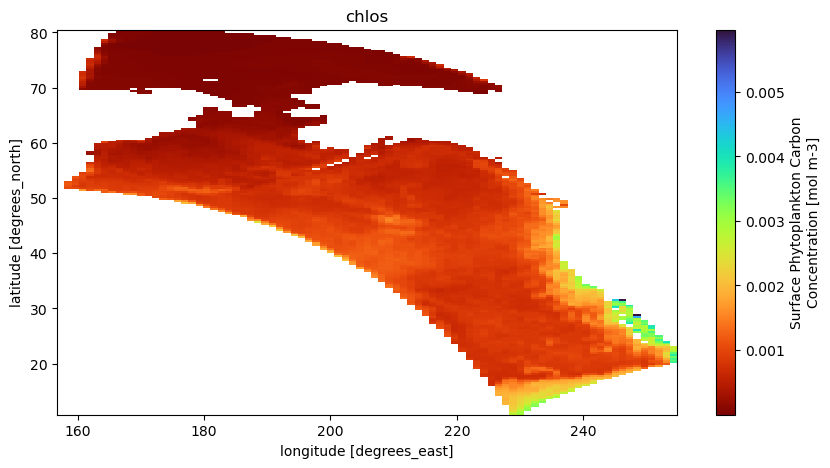

In [14]:
import matplotlib.pyplot as plt

da = ds["phycos"].isel(time=0).coarsen(
    lat=4,
    lon=4,
    boundary="trim",
).mean()

plt.figure(figsize=(10, 5))

da.plot(
    x="lon",
    y="lat",
    cmap="turbo_r",
)

plt.title("chlos")
plt.show()

## Interactive rasterized plot with hvPlot

This cell plots a 2D slice of `talk` using hvPlot. The data are first selected with slice indexing and squeezed to avoid memory issues with virtual arrays.


In [15]:
import hvplot.xarray

da = (
    ds["talk"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da.hvplot.quadmesh(
    rasterize=True,
    x="lon",
    y="lat",
    width=800,
    height=400,
    cmap = "turbo_r"
)

:DynamicMap   []
   :Image   [lon,lat]   (Total Alkalinity)

## Another memory-friendly plot example

This cell selects one time/depth slice of `no3`, coarsens the spatial grid, and plots the result. This is a safer pattern for quick-look plots from large virtual datasets.


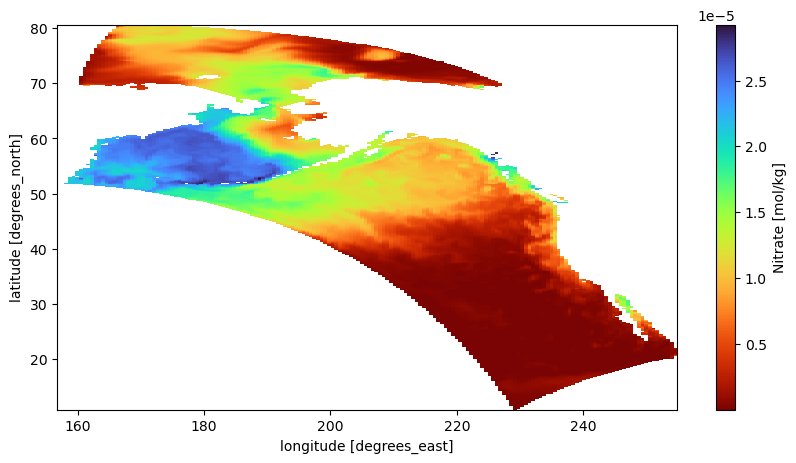

In [8]:
da = (
    ds["no3"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da_small = da.coarsen(
    lat=2,
    lon=2,
    boundary="trim",
).mean()

da_small.plot(
    x="lon",
    y="lat",
    figsize=(10, 5),
    cmap = "turbo_r"
)

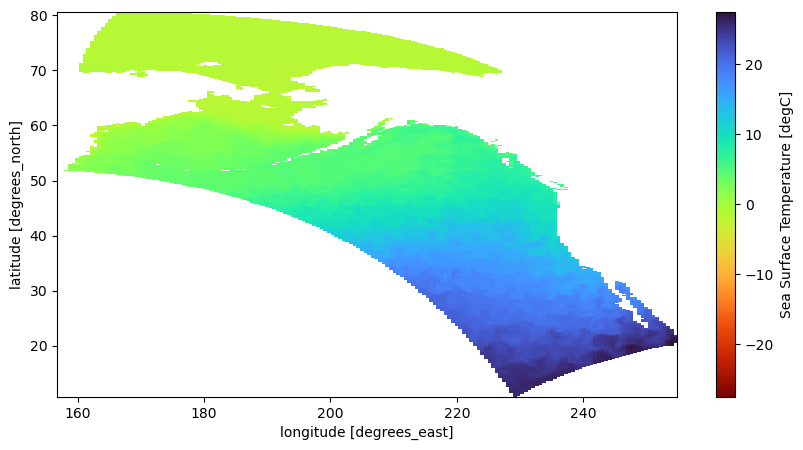

In [13]:
da = (
    ds2["tos"]
    .isel(time=slice(0, 1))
    .squeeze(drop=True)
)

da_small = da.coarsen(
    lat=2,
    lon=2,
    boundary="trim",
).mean()

da_small.plot(
    x="lon",
    y="lat",
    figsize=(10, 5),
    cmap = "turbo_r"
)

## TESTING

In [ ]:
%%script false --no-raise
# remove above if you want to run this cell

import json
import boto3

# Icechunk repo location on Source Cooperative
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"  # delete everything under this prefix

# Load temporary Source upload credentials
with open("source-cefi-creds.json") as f:
    source_creds = json.load(f)

icechunk_region = "us-west-2"

s3 = boto3.client(
    "s3",
    region_name=icechunk_region,
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds["aws_session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")
    total = 0

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        objects = [{"Key": obj["Key"]} for obj in page.get("Contents", [])]

        if objects:
            s3.delete_objects(
                Bucket=bucket,
                Delete={"Objects": objects},
            )
            total += len(objects)

    print(f"Deleted {total} objects from s3://{bucket}/{prefix}")

delete_s3_prefix(icechunk_bucket, icechunk_prefix)

In [13]:
%%script false --no-raise
# remove above if you want to run this cell

import json
import icechunk
import zarr

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

with open("source-cefi-creds.json") as f:
    source_creds = json.load(f)

storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

repo = icechunk.Repository.open(storage)
session = repo.writable_session(branch="main")

root = zarr.open_group(session.store, mode="a")

for group_name in ["monthly/main"]:
    if group_name in root:
        print(f"Deleting /{group_name}")
        del root[group_name]
    else:
        print(f"Not found: /{group_name}")

snapshot_id = session.commit("Remove temporary test groups")
print(snapshot_id)

Deleting /monthly/main
QJSWJCMD6BGBE5KK53Q0


In [2]:
import icechunk
import xarray as xr

# -------------------------------------------------------------------
# 1. Source data: original NOAA CEFI NetCDF files
# -------------------------------------------------------------------
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_prefix = "northeast_pacific/full_domain/hindcast/daily/regrid/r20250912"
source_data_region = "us-east-1"

source_data_url_prefix = source_data_bucket.rstrip("/") + "/"

# -------------------------------------------------------------------
# 2. Icechunk repo: public Source Cooperative location
# -------------------------------------------------------------------
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# -------------------------------------------------------------------
# 3. Authorize access to the original NOAA virtual chunks
# -------------------------------------------------------------------
# The Icechunk repo contains virtual references back to the public
# NOAA CEFI S3 bucket. Use anonymous access for these chunks.
credentials = icechunk.containers_credentials({
    source_data_url_prefix: icechunk.s3_credentials(anonymous=True)
})

# -------------------------------------------------------------------
# 4. Tell Icechunk which external virtual chunk locations are allowed
# -------------------------------------------------------------------
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=source_data_url_prefix,
        store=icechunk.s3_store(
            region=source_data_region,
            anonymous=True,
        ),
    ),
)

# -------------------------------------------------------------------
# 5. Point to the public Icechunk repo on Source Cooperative
# -------------------------------------------------------------------
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    anonymous=True,
)

# -------------------------------------------------------------------
# 6. Open the Icechunk repo
# -------------------------------------------------------------------
repo = icechunk.Repository.open(
    storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)

session_read = repo.readonly_session(branch="main")

In [3]:
ds = xr.open_zarr(
    session_read.store,
    group="monthly/main",
    consolidated=False, 
    chunks={}
)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 2TB
Dimensions:                      (time: 390, lat: 815, lon: 341, z_l: 52, zi: 76)
Coordinates:
  * time                         (time) datetime64[ns] 3kB 1993-01-16T12:00:0...
  * lat                          (lat) float64 7kB 10.81 10.89 ... 80.63 80.72
  * lon                          (lon) float64 3kB 156.9 157.2 ... 254.7 255.0
  * z_l                          (z_l) float64 416B 2.5 7.5 ... 6.25e+03
  * zi                           (zi) float64 608B 0.0 2.0 ... 6.25e+03 6.5e+03
Data variables: (12/356)
    FRAZIL                       (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    LSNK                         (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    MIB                          (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    bsios                        (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_ion                  (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    bfeos                        (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    ...                           ...
    wc_vert_int_nfix             (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zmicroos                     (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    wc_vert_int_npp              (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zmesoos                      (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zoocos                       (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    wc_vert_int_juptake_nh4      (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
Attributes: (12/28)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    grid_type:              regular
    grid_tile:              N/A
    NCO:                    netCDF Operators version 5.2.4 (Homepage = http:/...
    cefi_rel_path:          cefi_portal/northeast_pacific/full_domain/hindcas...
    ...                     ...
    associated_files:       areacello: 19930101.ocean_static.nc
    external_variables:     areacello
    cefi_ori_category:      ocean_cobalt_omip_sfc
    cefi_filename:          zoocos.nep.full.hcast.monthly.regrid.r20250912.19...
    cefi_variable:          zoocos
    cefi_ori_filename:      ocean_cobalt_omip_sfc.199301-202506.zoocos.nc

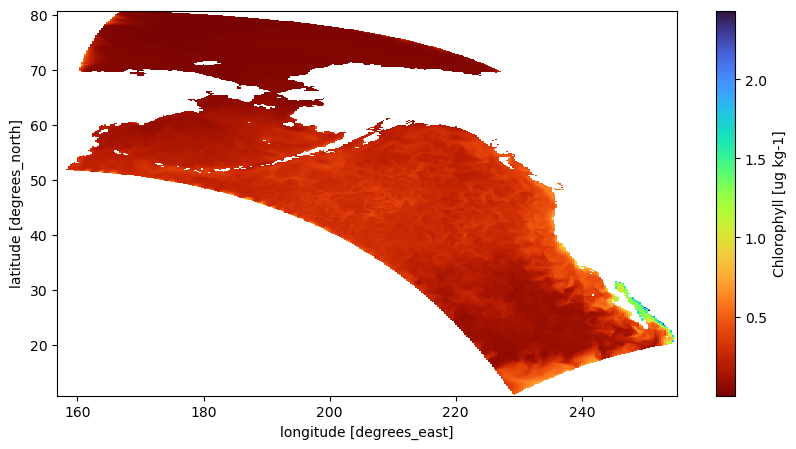

In [5]:
da = (
    ds["chl"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da_small = da.coarsen(
    lat=2,
    lon=2,
    boundary="trim",
).mean()

da.plot(
    x="lon",
    y="lat",
    figsize=(10, 5),
    cmap = "turbo_r"
)